# 03 — Where the model is wrong

A model is shipped on its average and judged on its mistakes. This notebook looks
at the ones it makes on the test split: who it misses, who it flags for nothing,
and whether either group has a shape.

The question is not "can the errors be removed" — they cannot — but "are they
distributed in a way the business can live with".

In [1]:
import warnings, os
warnings.filterwarnings("ignore")
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [2]:
from polaris.config import get_settings
from polaris.data import build_dataset
from polaris.registry.store import get_production

settings = get_settings()
dataset = build_dataset(settings)
production = get_production("churn-60d", settings)
model = production.load()["model"]
threshold = production.decision_threshold

frame = dataset.test.frame.copy()
frame["probability"] = model.predict_proba(dataset.test.X)[:, 1]
frame["flagged"] = frame.probability >= threshold
frame["actual"] = frame.churned_in_horizon.astype(bool)
frame["outcome"] = np.select(
    [frame.flagged & frame.actual, frame.flagged & ~frame.actual, ~frame.flagged & frame.actual],
    ["true positive", "false positive", "missed"],
    default="true negative",
)
frame.outcome.value_counts()

outcome
true negative     19410
false positive      853
missed              341
true positive       270
Name: count, dtype: int64

### The misses

The expensive error is a missed churn, because nothing was spent and the customer
still left. Are the misses systematically different from the catches?

In [3]:
interesting = ["seat_utilisation_28d", "usage_trend_28d_vs_90d", "days_since_last_use",
               "tickets_p1_90d", "last_nps_score", "mrr_eur", "tenure_days"]
churners = frame[frame.actual]
comparison = churners.groupby(churners.flagged.map({True: "caught", False: "missed"}))[interesting].median().T
comparison["difference"] = (comparison["missed"] - comparison["caught"]).round(2)
comparison.round(2)

flagged,caught,missed,difference
seat_utilisation_28d,0.16,0.27,0.11
usage_trend_28d_vs_90d,0.75,0.95,0.20
days_since_last_use,3.00,1.00,-2.00
tickets_p1_90d,1.00,1.00,0.00
last_nps_score,6.00,6.00,0.00
mrr_eur,256.47,331.72,75.25
tenure_days,1008.00,1073.00,65.00


The missed churns look **healthier** than the caught ones on every usage measure.
That is not a failure of the model so much as a statement about the problem: some
accounts leave for reasons that never appear in product telemetry — a budget cut,
an acquisition, a new CTO with a preferred vendor.

No feature in this store can see any of those. Saying so is more useful than
tuning against it.

In [4]:
by_segment = frame.groupby("segment").apply(
    lambda g: pd.Series({
        "rows": len(g),
        "churns": int(g.actual.sum()),
        "flagged": int(g.flagged.sum()),
        "precision": round(g.actual[g.flagged].mean(), 3) if g.flagged.any() else np.nan,
        "recall": round(g.flagged[g.actual].mean(), 3) if g.actual.any() else np.nan,
    }),
    include_groups=False,
)
by_segment

,rows,churns,flagged,precision,recall
segment,,,,,
enterprise,2490.0,4.0,1.0,1.000,0.250
mid_market,6518.0,173.0,204.0,0.235,0.277
smb,11866.0,434.0,918.0,0.241,0.509


### What the false positives cost

Each one is a 350 EUR retention play spent on an account that was not leaving. The
question is whether they are concentrated on cheap accounts (annoying) or on the
expensive ones (a customer success team's time is not free).

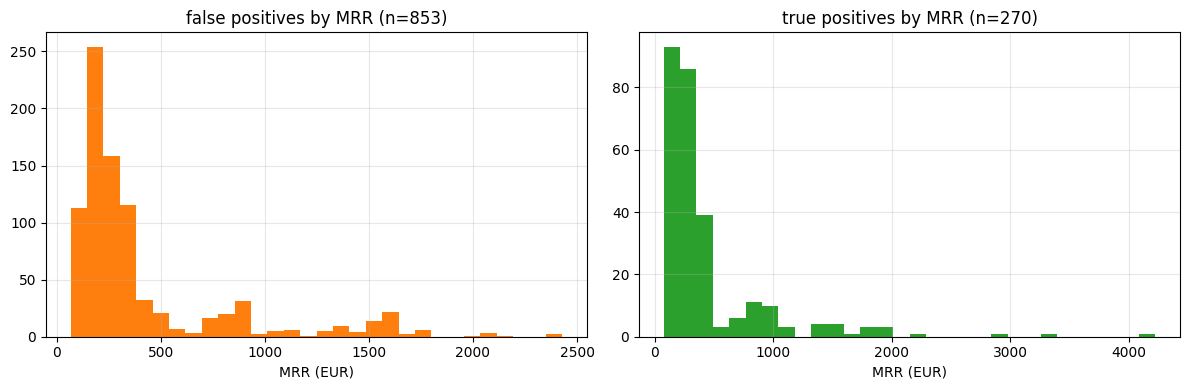

,count,median
outcome,,
false positive,853,252.0
missed,341,332.0
true negative,19410,435.0
true positive,270,256.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (outcome, colour) in zip(axes, [("false positive", "tab:orange"), ("true positive", "tab:green")]):
    subset = frame[frame.outcome == outcome]
    ax.hist(subset.mrr_eur.clip(upper=frame.mrr_eur.quantile(0.98)), bins=30, color=colour)
    ax.set_title(f"{outcome}s by MRR (n={len(subset)})")
    ax.set_xlabel("MRR (EUR)")
plt.tight_layout(); plt.show()

frame.groupby("outcome").mrr_eur.agg(["count", "median"]).round(0)

### The honest summary

* The model finds a real signal and finds it early enough to act on.
* It misses the churns that product telemetry cannot see, and those misses are not
  fixable with the data in this store.
* Its false positives are spread across account sizes rather than concentrated on
  the largest ones, which is the acceptable of the two shapes.

The next improvement is not a better algorithm. It is a feature the source system
does not currently carry — renewal-conversation notes, or a support escalation
flag — and that is a conversation with the product team, not a hyperparameter.